In [1]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 12
       }

plt.rcParams['axes.grid'] = True
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=12) 
matplotlib.rc('ytick', labelsize=12) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
    
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def plot_fig(i, control):
    lines = 2
    height = lines * 3
    fig, axes = plt.subplots(lines,2, figsize=(18, height))
    axes[0,i].plot(aln.t, control[0,0,:], label="control exc")
    axes[0,i+1].plot(aln.t, control[0,1,:], label="control inh")
    axes[1,i].plot(aln.t, aln.state["rates_exc"][0,:], label="rates exc")
    axes[1,i+1].plot(aln.t, aln.state["rates_inh"][0,:], label="rates inh")
    
    """
    axes[2,i].plot(aln.t, aln.state["mufe"][0,:], label="mufe")
    axes[2,i+1].plot(aln.t, aln.state["mufi"][0,:], label="mufi")
    #axes[3,i].plot(aln.t, aln.state["IA"][0,:], label="IA")

    axes[4,i].plot(aln.t, aln.state["seem"][0,:], label="seem")
    axes[3,i].plot(aln.t, aln.state["seim"][0,:], label="seim")
    axes[4,i+1].plot(aln.t, aln.state["siem"][0,:], label="siem")
    axes[3,i+1].plot(aln.t, aln.state["siim"][0,:], label="siim")

    axes[5,i].plot(aln.t, aln.state["seev"][0,:], label="seev")
    axes[5,i+1].plot(aln.t, aln.state["seiv"][0,:], label="seiv")
    axes[6,i].plot(aln.t, aln.state["siev"][0,:], label="siev")
    axes[6,i+1].plot(aln.t, aln.state["siiv"][0,:], label="siiv")

    #axes[6,i].plot(aln.t, aln.state["mue_ou"][0,:], label="mue_ou")
    #axes[6,i+1].plot(aln.t, aln.state["mui_ou"][0,:], label="mui_ou")

    axes[7,i].plot(aln.t, aln.state["sigmae_f"][0,:], label="sigma_e")
    axes[7,i+1].plot(aln.t, aln.state["sigmai_f"][0,:], label="sigma_i")
    #axes[8,i].plot(aln.t, aln.state["Vmean_exc"][0,:], label="V_mean")
    #axes[9,i].plot(aln.t, aln.state["tau_exc"][0,:], label="tau_exc")
    #axes[9,i+1].plot(aln.t, aln.state["tau_inh"][0,:], label="tau_inh")
    """

    for k in range(lines):
        for j in range(2):
            #if ((k,j) != (3,1) and (k,j) != (8,1)):
            axes[k,j].legend()

    plt.tight_layout()
    
def plot_dif(diff_):
    fig, axes = plt.subplots(1,2, figsize=(18, 3))
    axes[0].plot(aln.t, diff_[0,:], label="difference in exc rate")
    axes[1].plot(aln.t, diff_[1,:], label="difference in inh rate")

    for j in range(2):
        axes[j].legend()

    plt.tight_layout()
    
def plot_phi(phi):
    lines = 9
    time = np.arange(0, dur+aln.params.dt, aln.params.dt)
    
    fig, axes = plt.subplots(lines,2, figsize=(18, 26))
    
    axes[0,0].plot(time, phi[0,0,:], label="phi0 - adjoint exc rate")
    axes[0,1].plot(time, phi[0,1,:], label="phi1 - adjoint inh rate")
    
    axes[1,0].plot(time, phi[0,2,:], label="phi2 - adjoint mufe")
    axes[1,1].plot(time, phi[0,3,:], label="phi3 - adjoint mufi")
    
    axes[2,0].plot(time, phi[0,6,:], label="phi6 - adjoint seim")
    axes[2,1].plot(time, phi[0,8,:], label="phi8 - adjoint siim")
    
    axes[3,0].plot(time, phi[0,4,:], label="phi4 - adjoint IA")
    axes[3,1].plot(time, phi[0,17,:], label="phi17 - adjoint V")
    
    axes[4,0].plot(time, phi[0,5,:], label="phi6 - adjoint seem")
    axes[4,1].plot(time, phi[0,7,:], label="phi8 - adjoint siem")
    
    axes[5,0].plot(time, phi[0,9,:], label="phi9 - adjoint seev")
    axes[5,0].plot(time, phi[0,10,:], label="phi10 - adjoint seiv")
    axes[5,1].plot(time, phi[0,11,:], label="phi11 - adjoint siev")
    axes[5,1].plot(time, phi[0,12,:], label="phi12 - adjoint siiv")
    
    axes[6,0].plot(time, phi[0,13,:], label="phi13 - adjoint mue ou")
    axes[6,1].plot(time, phi[0,14,:], label="phi14 - adjoint mui ou")
    
    axes[7,0].plot(time, phi[0,15,:], label="phi15 - adjoint sigma e")
    axes[7,1].plot(time, phi[0,16,:], label="phi16 - adjoint sigma i")
    
    axes[8,0].plot(time, phi[0,18,:], label="phi18 - adjoint tau e")
    axes[8,1].plot(time, phi[0,19,:], label="phi19 - adjoint tau i")

    for k in range(lines):
        for j in range(2):
            axes[k,j].legend()

    plt.tight_layout()

def diff_control(diff_):
    d_int = 0.
    for n in range(diff_.shape[0]):
        for v in range(diff_.shape[1]):
            for t in range(diff_.shape[2]):
                d_int += np.abs(diff_[n,v,t]) * aln.params.dt
    return d_int
            
def setparams():
    
    # default
    aln.params.mue_ext_mean = 0.4
    aln.params.mui_ext_mean = 0.3
    
    aln.params.sigmae_ext = 1.5
    aln.params.sigmai_ext = 1.5
    
    aln.params.ext_exc_current = 0.
    aln.params.ext_inh_current = 0.
    
    aln.params.di = 0.0
    aln.params.de = 0.0
    aln.params.signalV = 0.
    
def set_init(init_v_):
    init_vars = aln.init_vars
    for i in range(len(init_vars)):
        if aln.params[init_vars[i]].size == 1:
            aln.params[init_vars[i]][0] = init_v_[i]
        else:
            aln.params[init_vars[i]][0,-1] = init_v_[i]
    
rates_exc_init = np.array( [[ 33. ]] )
rates_inh_init = np.array( [[44. ]] )
mufe_init = np.array( [[1.5 ]] )  # mV/ms
mufi_init = np.array( [[1.5 ]] )  # mV/ms
IA_init = np.array( [[100. ]] )  # pA
seem_init = np.array( [[0.5 * 0.5 ]] )
seim_init = np.array( [[0.5 * 0.5 ]] )   
seev_init = np.array( [[0.01 * 0.5 ]] )
seiv_init = np.array( [[0.01 * 0.5 ]] )
siim_init = np.array( [[0.5 * 0.5 ]] )
siem_init = np.array( [[0.5 * 0.5 ]] )
siiv_init = np.array( [[0.01 * 0.5 ]] )
siev_init = np.array( [[0.01 * 0.5 ]] )
mue_ou = np.array( [[0.4 ]] )
mui_ou = np.array( [[0.3 ]] )

initvars = np.array( [
rates_exc_init,
rates_inh_init,
mufe_init,
mufi_init,
IA_init,
seem_init ,
seim_init,
seev_init,
seiv_init,
siim_init,
siem_init,
siiv_init,
siev_init,
mue_ou,
mui_ou
    ])

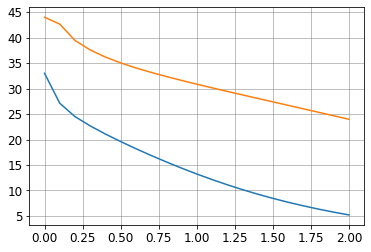

In [3]:
aln = ALNModel()
setparams()
set_init(initvars)

dur = 2.
aln.params['duration'] = dur

control0 = aln.getZeroControl()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

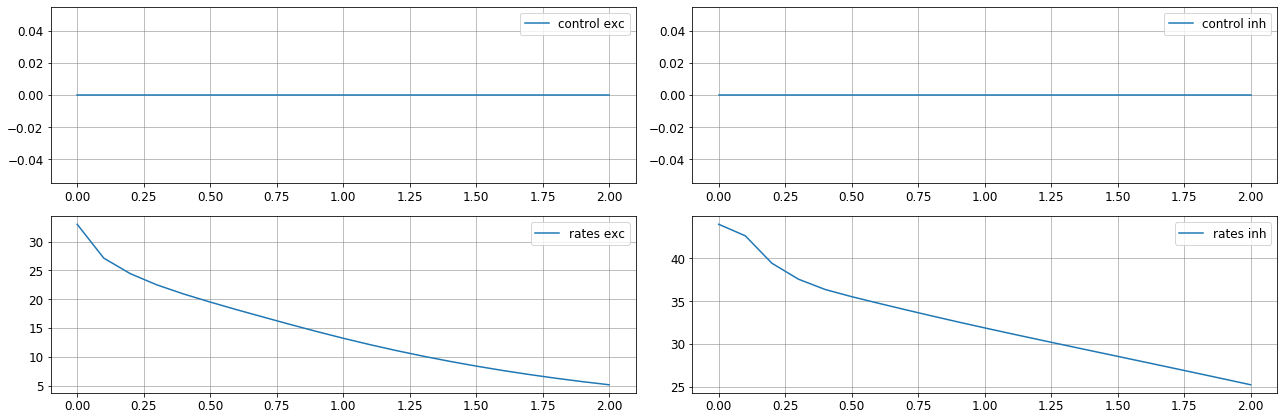

In [4]:
dur_pre = 0.
dur_post = 0.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

target = aln.getZeroTarget()
control1 = aln.getZeroControl()

set_init(initvars)
setparams()

aln.params.de = 0.2
aln.params.di = 0.4

aln.params.cee = 0.3   #0.3
aln.params.cie = 0.3   #0.3
aln.params.cei = 0.5  #0.5
aln.params.cii = 0.5  #0.5

aln.params.Jee_max = 2.43
aln.params.Jie_max = 2.60
aln.params.Jei_max = -3.3
aln.params.Jii_max = -1.64
    
aln.run(control=control1)
plot_fig(0, control1)
rates0 = np.array( [aln.state["rates_exc"][0,:], aln.state["rates_inh"][0,:]] )

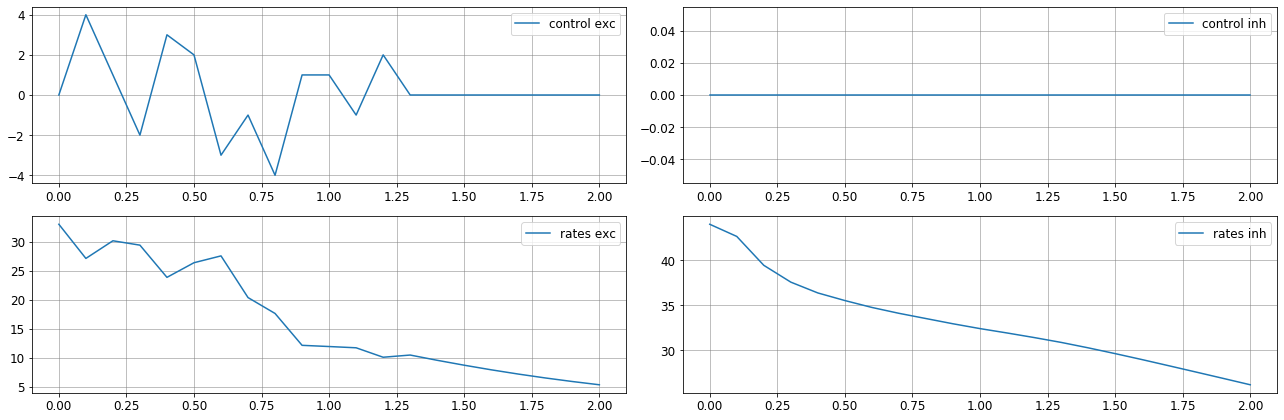

In [5]:
control1 = aln.getZeroControl()
control1[0,0,1] += 4.
control1[0,0,2] += 1.
control1[0,0,3] -= 2.
control1[0,0,4] += 3.
control1[0,0,5] += 2.
control1[0,0,6] -= 3.
control1[0,0,7] -= 1.
control1[0,0,8] -= 4.
control1[0,0,9] += 1.
control1[0,0,10] += 1.
control1[0,0,11] -= 1.
control1[0,0,12] += 2.

control2 = aln.getZeroControl()
control2[0,0,1:12] += np.sin(6.*np.arange(0,1.1,aln.params.dt))

apply_control = control1

aln.run(control=apply_control)
plot_fig(0, apply_control)
plt.savefig("inh_control.png")

rates1 = np.array( [aln.state["rates_exc"][0,:], aln.state["rates_inh"][0,:]] )
target[:,0,:] = aln.state["rates_exc"][0,:]
target[:,1,:] = aln.state["rates_inh"][0,:]

[ 0.      0.      5.7404  6.9337  2.9637  6.8816  9.3923  3.495   2.0271
 -2.229  -1.2626 -0.3714 -0.9611  0.3824  0.3747  0.3578  0.3306  0.3023
  0.2774  0.256   0.2356]


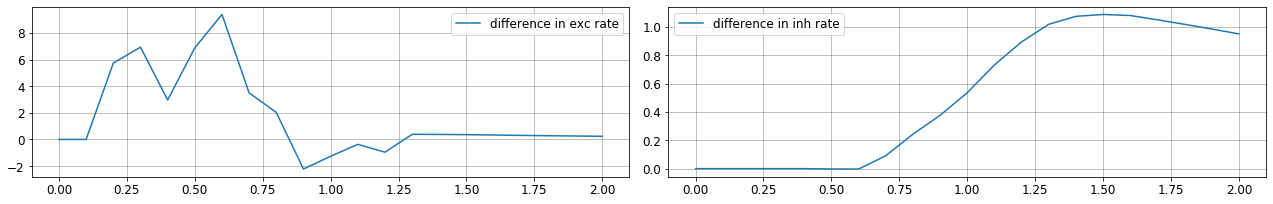

In [6]:
diff = rates1 - rates0
plot_dif(diff)
plt.savefig("diff.png")
print(diff[0,:])

In [10]:
max_cntrl = 50. * 5.
start_step = 100.
tol = 1e-40

cost_params = [1.0, 0.0, 0.0]
cost.setParams(cost_params[0], cost_params[1], cost_params[2])

test_control = aln.getZeroControl()
test_control = A1_bestControl

max_it = 2000
set_init(initvars)

A1_bestControl, A1_bestState, A1_cost, runtime = aln.A1(test_control, target, c_scheme, u_mat,
        u_scheme, max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        variables_ = [1])

ERROR:root:Not possible to set up initial conditions without sufficient simulation time before control


set cost params
True 4
RUN  0 , total integrated cost =  2.0048059736633444e-05
RUN  1 , total integrated cost =  1.9988546002984022e-05
RUN  2 , total integrated cost =  1.9966121981087532e-05
RUN  3 , total integrated cost =  1.9944036648056098e-05
RUN  4 , total integrated cost =  1.9896057152166887e-05
RUN  5 , total integrated cost =  1.9845249190214637e-05
RUN  6 , total integrated cost =  1.9842484545755977e-05
RUN  7 , total integrated cost =  1.983878518386154e-05
RUN  8 , total integrated cost =  1.9836219052479746e-05
RUN  9 , total integrated cost =  1.9832261254386596e-05
RUN  10 , total integrated cost =  1.982931706516976e-05
RUN  11 , total integrated cost =  1.9823683056944278e-05
RUN  12 , total integrated cost =  1.9819116580098515e-05
RUN  13 , total integrated cost =  1.9798917090108935e-05
RUN  14 , total integrated cost =  1.9781450611909117e-05
RUN  15 , total integrated cost =  1.972280841755462e-05
RUN  16 , total integrated cost =  1.966070400906569e-05
RUN  

RUN  143 , total integrated cost =  1.7664121675005465e-05
RUN  144 , total integrated cost =  1.764914105074468e-05
RUN  145 , total integrated cost =  1.7611518773553186e-05
RUN  146 , total integrated cost =  1.7575186581112055e-05
RUN  147 , total integrated cost =  1.7573056424909557e-05
RUN  148 , total integrated cost =  1.757020742366355e-05
RUN  149 , total integrated cost =  1.756826921631323e-05
RUN  150 , total integrated cost =  1.756549286431835e-05
RUN  151 , total integrated cost =  1.756346300488102e-05
RUN  152 , total integrated cost =  1.755988011228133e-05
RUN  153 , total integrated cost =  1.7556867042939577e-05
RUN  154 , total integrated cost =  1.7551856000609904e-05
RUN  155 , total integrated cost =  1.7547609577602208e-05
RUN  156 , total integrated cost =  1.7535676118883666e-05
RUN  157 , total integrated cost =  1.7523906877341612e-05
RUN  158 , total integrated cost =  1.7477450446887126e-05
RUN  159 , total integrated cost =  1.7433453982129874e-05
RUN

RUN  287 , total integrated cost =  1.3859228382841722e-05
RUN  288 , total integrated cost =  1.3823919714007468e-05
RUN  289 , total integrated cost =  1.381139252385809e-05
RUN  290 , total integrated cost =  1.379797621761073e-05
RUN  291 , total integrated cost =  1.3761167568207126e-05
RUN  292 , total integrated cost =  1.3724128437703511e-05
RUN  293 , total integrated cost =  1.3712686655683898e-05
RUN  294 , total integrated cost =  1.3700989929911414e-05
RUN  295 , total integrated cost =  1.369981938043222e-05
RUN  296 , total integrated cost =  1.3698425844237121e-05
RUN  297 , total integrated cost =  1.3697434918341271e-05
RUN  298 , total integrated cost =  1.3696126736092128e-05
RUN  299 , total integrated cost =  1.3695125371864158e-05
RUN  300 , total integrated cost =  1.3693773023454715e-05
RUN  301 , total integrated cost =  1.3692663385918576e-05
RUN  302 , total integrated cost =  1.3690673264099296e-05
RUN  303 , total integrated cost =  1.3688869688354393e-05


RUN  431 , total integrated cost =  1.1379876118473093e-05
RUN  432 , total integrated cost =  1.136154657443887e-05
RUN  433 , total integrated cost =  1.1343694899668221e-05
RUN  434 , total integrated cost =  1.1335481376691654e-05
RUN  435 , total integrated cost =  1.1326871373871189e-05
RUN  436 , total integrated cost =  1.1308770264049205e-05
RUN  437 , total integrated cost =  1.1291179577220121e-05
RUN  438 , total integrated cost =  1.1283091740079307e-05
RUN  439 , total integrated cost =  1.127458181595344e-05
RUN  440 , total integrated cost =  1.1256829969138957e-05
RUN  441 , total integrated cost =  1.123936668578959e-05
RUN  442 , total integrated cost =  1.1231460192870125e-05
RUN  443 , total integrated cost =  1.1222988847633608e-05
RUN  444 , total integrated cost =  1.120570367261293e-05
RUN  445 , total integrated cost =  1.1188238049688125e-05
RUN  446 , total integrated cost =  1.118056534989489e-05
RUN  447 , total integrated cost =  1.1173293127409921e-05
RU

...

RUN  1424 , total integrated cost =  7.83087645118641e-06
RUN  1425 , total integrated cost =  7.830599291231814e-06
RUN  1426 , total integrated cost =  7.83032626338021e-06
RUN  1427 , total integrated cost =  7.83005693531029e-06
RUN  1428 , total integrated cost =  7.829786525651804e-06
RUN  1429 , total integrated cost =  7.829514685911106e-06
RUN  1430 , total integrated cost =  7.829236430119995e-06
RUN  1431 , total integrated cost =  7.828958024184269e-06
RUN  1432 , total integrated cost =  7.828665269805277e-06
RUN  1433 , total integrated cost =  7.828380988625571e-06
RUN  1434 , total integrated cost =  7.828095071579426e-06
RUN  1435 , total integrated cost =  7.827804361308837e-06
RUN  1436 , total integrated cost =  7.82752401430478e-06
RUN  1437 , total integrated cost =  7.827247778138896e-06
RUN  1438 , total integrated cost =  7.826974565292517e-06
RUN  1439 , total integrated cost =  7.826706871651293e-06
RUN  1440 , total integrated cost =  7.82643767149778e-06
RU

RUN  1564 , total integrated cost =  7.792286059205343e-06
RUN  1565 , total integrated cost =  7.792020861453442e-06
RUN  1566 , total integrated cost =  7.791748473897294e-06
RUN  1567 , total integrated cost =  7.791476339751328e-06
RUN  1568 , total integrated cost =  7.791196675926402e-06
RUN  1569 , total integrated cost =  7.790910760721761e-06
RUN  1570 , total integrated cost =  7.790625010300942e-06
RUN  1571 , total integrated cost =  7.790346030265785e-06
RUN  1572 , total integrated cost =  7.790072997482616e-06
RUN  1573 , total integrated cost =  7.789801987947394e-06
RUN  1574 , total integrated cost =  7.789521256603737e-06
RUN  1575 , total integrated cost =  7.789236812400232e-06
RUN  1576 , total integrated cost =  7.788949888033767e-06
RUN  1577 , total integrated cost =  7.788671910108726e-06
RUN  1578 , total integrated cost =  7.788398220417817e-06
RUN  1579 , total integrated cost =  7.788128245818235e-06
RUN  1580 , total integrated cost =  7.787861386580001e-

RUN  1705 , total integrated cost =  7.753685960687056e-06
RUN  1706 , total integrated cost =  7.75342120412979e-06
RUN  1707 , total integrated cost =  7.753158789138166e-06
RUN  1708 , total integrated cost =  7.752894366775797e-06
RUN  1709 , total integrated cost =  7.752632186202872e-06
RUN  1710 , total integrated cost =  7.752368075025104e-06
RUN  1711 , total integrated cost =  7.752105792606491e-06
RUN  1712 , total integrated cost =  7.751835639488825e-06
RUN  1713 , total integrated cost =  7.751566629661346e-06
RUN  1714 , total integrated cost =  7.751289145567594e-06
RUN  1715 , total integrated cost =  7.751006577082855e-06
RUN  1716 , total integrated cost =  7.750723040604616e-06
RUN  1717 , total integrated cost =  7.750447176539091e-06
RUN  1718 , total integrated cost =  7.750176409595608e-06
RUN  1719 , total integrated cost =  7.74990847699247e-06
RUN  1720 , total integrated cost =  7.749629976622988e-06
RUN  1721 , total integrated cost =  7.74934881554678e-06


RUN  1846 , total integrated cost =  7.715522655113607e-06
RUN  1847 , total integrated cost =  7.715262870246503e-06
RUN  1848 , total integrated cost =  7.71500083614288e-06
RUN  1849 , total integrated cost =  7.714741272181933e-06
RUN  1850 , total integrated cost =  7.714479448372752e-06
RUN  1851 , total integrated cost =  7.714213431161475e-06
RUN  1852 , total integrated cost =  7.713945321761085e-06
RUN  1853 , total integrated cost =  7.713671706919287e-06
RUN  1854 , total integrated cost =  7.713390457462585e-06
RUN  1855 , total integrated cost =  7.713110882073199e-06
RUN  1856 , total integrated cost =  7.712836000062269e-06
RUN  1857 , total integrated cost =  7.71256942585536e-06
RUN  1858 , total integrated cost =  7.71230232202797e-06
RUN  1859 , total integrated cost =  7.712027763812837e-06
RUN  1860 , total integrated cost =  7.711747837403643e-06
RUN  1861 , total integrated cost =  7.711467223285143e-06
RUN  1862 , total integrated cost =  7.711193235742084e-06


RUN  1990 , total integrated cost =  7.676981219188628e-06
RUN  1991 , total integrated cost =  7.676704320504773e-06
RUN  1992 , total integrated cost =  7.676431706065041e-06
RUN  1993 , total integrated cost =  7.676167676453782e-06
RUN  1994 , total integrated cost =  7.675902740142034e-06
RUN  1995 , total integrated cost =  7.675630835269364e-06
RUN  1996 , total integrated cost =  7.67535315383616e-06
RUN  1997 , total integrated cost =  7.675075276033003e-06
RUN  1998 , total integrated cost =  7.674803512008133e-06
RUN  1999 , total integrated cost =  7.674538950983187e-06
RUN  2000 , total integrated cost =  7.67427461305437e-06
Improved over  2000  iterations by  61.72061180049602  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([0], dtype=int64), array([3], dtype=int64)) 1.1676789926556325e-05
min value of final gradient at index =  (array([0], dtype=int64), array([0], dtype=int64), array([2], dtype=int64)) -5.3818740472292395e-05


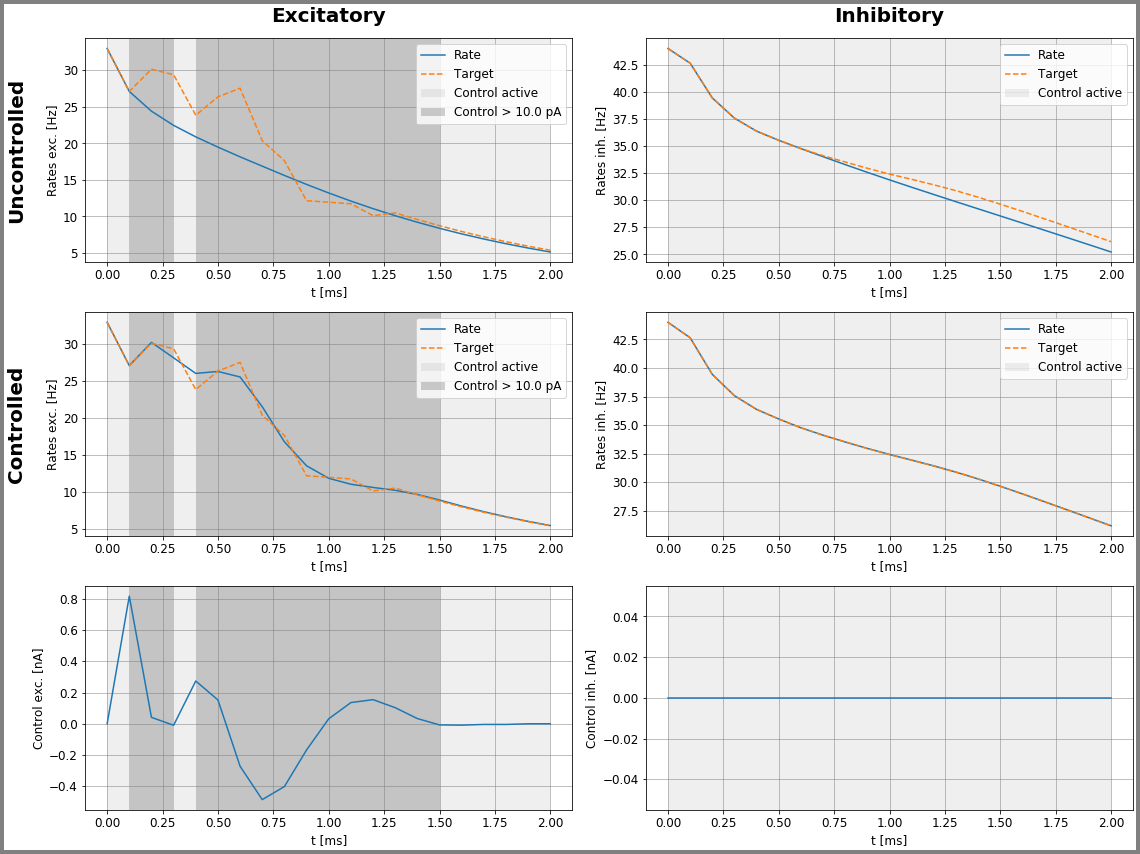

In [8]:
plotFunc.plot_control(aln, A1_bestControl, dur, dur_pre, dur_post, initvars, target,
                      path, filename_ = 'a1_inh.png')

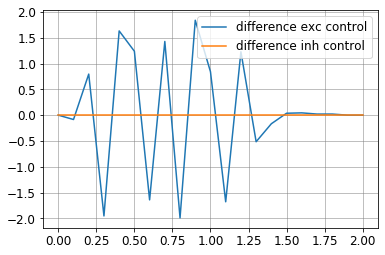

control difference =  1.714905227319776


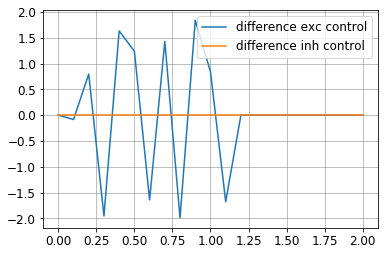

control difference =  1.5116629066999565


In [9]:
cDiff = apply_control - A1_bestControl
plt.plot(aln.t, cDiff[0,0,:], label="difference exc control")
plt.plot(aln.t, cDiff[0,1,:], label="difference inh control")
plt.legend()
plt.show()

d_int = diff_control(cDiff)
print("control difference = ", d_int)

cDiff[0,0,12:] = 0.
cDiff[0,0,0] = 0.
plt.plot(aln.t, cDiff[0,0,:], label="difference exc control")
plt.plot(aln.t, cDiff[0,1,:], label="difference inh control")
plt.legend()
plt.show()

d_int = diff_control(cDiff)
print("control difference = ", d_int)